# Naive Bayes Model

In this section, we implement Naive Bayes model as a baseline for phishing website detection.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load Clean Dataset
df = pd.read_csv("../../data/processed-phishing.csv")

In [3]:
# Separate features and target variable
X = df.drop("Result", axis=1)
y = df["Result"]

print(X.shape)
print(y.shape)

(5849, 30)
(5849,)


## Baseline Naive Bayes (GaussianNB)

We first apply Gaussian Naive Bayes as a baseline model.

Gaussian Naive Bayes assumes that features follow a normal (Gaussian) distribution, which may not be appropriate for this dataset.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

nb_base = GaussianNB()
nb_base.fit(X_train, y_train)

y_pred_base = nb_base.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))

Baseline Accuracy: 0.6547008547008547


## Baseline Results

The Gaussian Naive Bayes model shows relatively poor performance.

This is because:
- The feature values (-1, 0, 1) do not follow a Gaussian distribution
- The independence assumption is violated due to feature correlations

## Improved Naive Bayes (BernoulliNB)

To improve performance, we modify the feature representation and use Bernoulli Naive Bayes.

Key improvements:
- Convert features into binary phishing-signal indicators
- Use BernoulliNB, which is better suited for binary data

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# target replacement
y = y.replace({-1: 0, 1: 1})


# feature replacement
X_binary = X.replace({-1: 1, 0: 0, 1: 0})

In [6]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# Create the Improved Naive Bayes Model
nb = BernoulliNB(alpha=1.0)

# CV on train set before final test evaluation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    nb,
    X_train,
    y_train,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1,
)
print(f"CV Accuracy: {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")

# Train the model
nb.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb.predict(X_test)

In [8]:
# Evaluate the model
print("Naive Bayes Results:")
print()

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print()

Naive Bayes Results:

Accuracy: 0.8923076923076924
Precision: 0.8728813559322034
Recall: 0.9098939929328622
F1 Score: 0.8910034602076125



Confusion Matrix:
[[529  75]
 [ 51 515]]


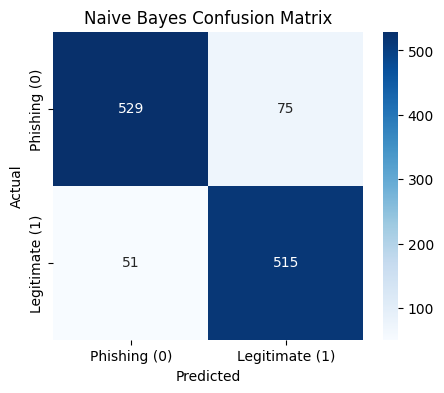

In [9]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))


# Confusion Matrix Visualization
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Phishing (0)", "Legitimate (1)"],
    yticklabels=["Phishing (0)", "Legitimate (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [10]:
# Check for overfitting
y_train_pred_nb = nb.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_nb))
print("Test Accuracy:", accuracy_score(y_test, y_pred_nb))

Train Accuracy: 0.9040393246420175
Test Accuracy: 0.8923076923076924


## Results

The improved Naive Bayes model achieved significantly better performance:
- Accuracy: ~89%
- Precision: ~0.87
- Recall: ~0.91
- F1 Score: ~0.89
  
Compared to the baseline Gaussian Naive Bayes, performance improved substantially.

## Analysis

The improved Naive Bayes model demonstrates a strong balance between precision and recall.
The performance gain is mainly due to:
- using Bernoulli Naive Bayes instead of Gaussian Naive Bayes
- transforming features into binary representations

The model achieves high recall, meaning it successfully detects most phishing websites, while also reducing false positives. However, Naive Bayes still assumes feature independence, which limits its ability to capture complex relationships between features. Therefore, although the performance improved significantly, it is still expected to be lower than tree-based models.


Top 10 Most Discriminative Features (Naive Bayes Approximation):
                   Feature  Phishing_log_prob  Legitimate_log_prob  \
13           URL_of_Anchor          -0.420052            -4.953183   
7           SSLfinal_State          -0.480401            -2.412565   
14           Links_in_tags          -0.700206            -1.364469   
29      Statistical_report          -1.641814            -2.196342   
12             Request_URL          -0.599606            -1.150696   
27            Google_Index          -1.542240            -2.080325   
25             web_traffic          -1.147796            -1.678399   
28  Links_pointing_to_page          -3.165310            -2.721825   
17            Abnormal_URL          -2.031381            -1.632202   
6        having_Sub_Domain          -1.054502            -1.447250   

    Absolute_Difference  
13             4.533131  
7              1.932165  
14             0.664263  
29             0.554528  
12             0.551089  
27     

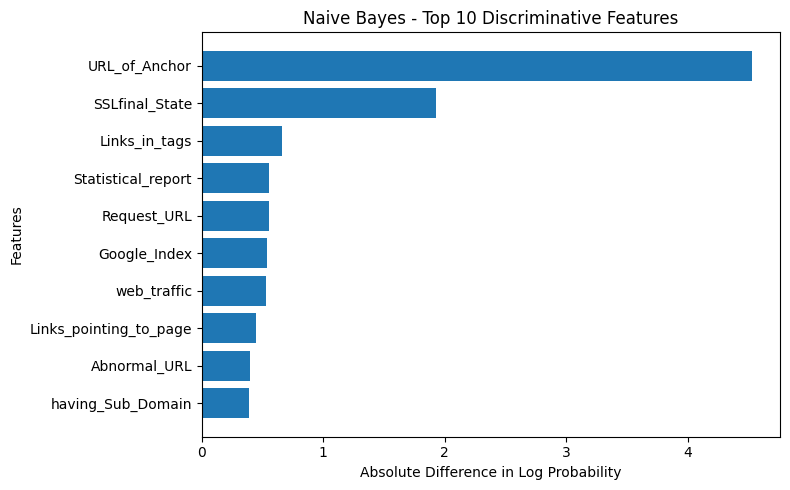

In [12]:
# Feature influence approximation
feature_analysis = pd.DataFrame({
    "Feature": X_binary.columns,
    "Phishing_log_prob": nb.feature_log_prob_[0],
    "Legitimate_log_prob": nb.feature_log_prob_[1],
    "Absolute_Difference": np.abs(nb.feature_log_prob_[0] - nb.feature_log_prob_[1])
}).sort_values(by="Absolute_Difference", ascending=False)

print()
print("Top 10 Most Discriminative Features (Naive Bayes Approximation):")
print(feature_analysis.head(10))

# Plot top 10 discriminative features
top10 = feature_analysis.head(10).sort_values(by="Absolute_Difference", ascending=True)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Absolute_Difference"])
plt.title("Naive Bayes - Top 10 Discriminative Features")
plt.xlabel("Absolute Difference in Log Probability")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Feature Analysis

Unlike tree-based models, Naive Bayes does not provide traditional feature importance scores.
Instead, we analyze feature influence using the difference in log probabilities between classes.

Specifically, we compute:
| log P(feature | phishing) - log P(feature | legitimate) |

Features with larger differences are more discriminative and contribute more to classification.

The most discriminative features include:
- URL_of_Anchor
- SSLfinal_State
- Links_in_tags

These features show strong differences between phishing and legitimate websites, making them important for prediction.